# Visualize JWST_DINO Augmentations

Compare one raw JWST cutout with the current `DataAugmentationJWSTDINO` multi-crop outputs.

In [1]:
from pathlib import Path
import os
import random
import sys

import matplotlib.pyplot as plt
import numpy as np
import torch


def find_repo_root(start: Path) -> Path:
    start = start.resolve()
    for path in (start, *start.parents):
        if (path / "pyproject.toml").exists() and (path / "encoder_image").exists():
            return path
    raise RuntimeError("Could not find repo root. Start Jupyter from inside ssl_outthere.")


REPO_ROOT = find_repo_root(Path.cwd())
sys.path.insert(0, str(REPO_ROOT))

from encoder_image.jwst_dino.data.augmentations import AsinhStretch, DataAugmentationJWSTDINO
from encoder_image.jwst_dino.data.dataset import JWST, parse_tile

print(REPO_ROOT)

/nexus/posix0/MIA-astro-env/ivemo/yacheng/ssl_outthere


In [9]:
# Edit these knobs as needed.
DATA_ROOT = Path(os.environ.get("JWST_DINO_DATA_ROOT", "~/ssl_outthere/data/image/")).expanduser()
FILTER = "f150w"
SURVEY = "cosmos"
SPLIT = "train"
SAMPLE_INDEX = 0
SEED = 42

AUG_KWARGS = dict(
    local_crops_number=8,
    global_crops_size=72,
    local_crops_size=36,
    center_crop_size=100,
    noise_w=2.0,
    noise_s_max=None,
)

print(DATA_ROOT)

/home/yacheng/ssl_outthere/data/image


In [10]:
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

raw_ds = JWST(split=SPLIT, root=str(DATA_ROOT), filter=FILTER, survey=SURVEY, transform=None)
aug = DataAugmentationJWSTDINO(**AUG_KWARGS)

row = raw_ds.indices[SAMPLE_INDEX]
rel_path = raw_ds.rel_path[row]
tile = parse_tile(rel_path)
raw_tensor, _ = raw_ds[SAMPLE_INDEX]
views = aug(raw_tensor.clone(), tile=tile)

print(f"split={SPLIT} sample_index={SAMPLE_INDEX} row={row} tile={tile} rel_path={rel_path}")
print(f"raw shape: {tuple(raw_tensor.shape)}")
print("global shapes:", [tuple(x.shape) for x in views["global_crops"]])
print("local shapes:", [tuple(x.shape) for x in views["local_crops"]])

JWST [train] — 683507 / 759453 cutouts (f150w)
###################################
Using data augmentation parameters:
local_crops_number: 8
global_crops_size: 72
local_crops_size: 36
center_crop_size: 100
noise_w: 2.0  noise_s_max: None
###################################
Model input image: 72x72
####################################

split=train sample_index=0 row=722586 tile=B9 rel_path=f150w/nircam_cosmos_f150w_B9.npy
raw shape: (1, 128, 128)
global shapes: [(1, 72, 72), (1, 72, 72)]
local shapes: [(1, 36, 36), (1, 36, 36), (1, 36, 36), (1, 36, 36), (1, 36, 36), (1, 36, 36), (1, 36, 36), (1, 36, 36)]


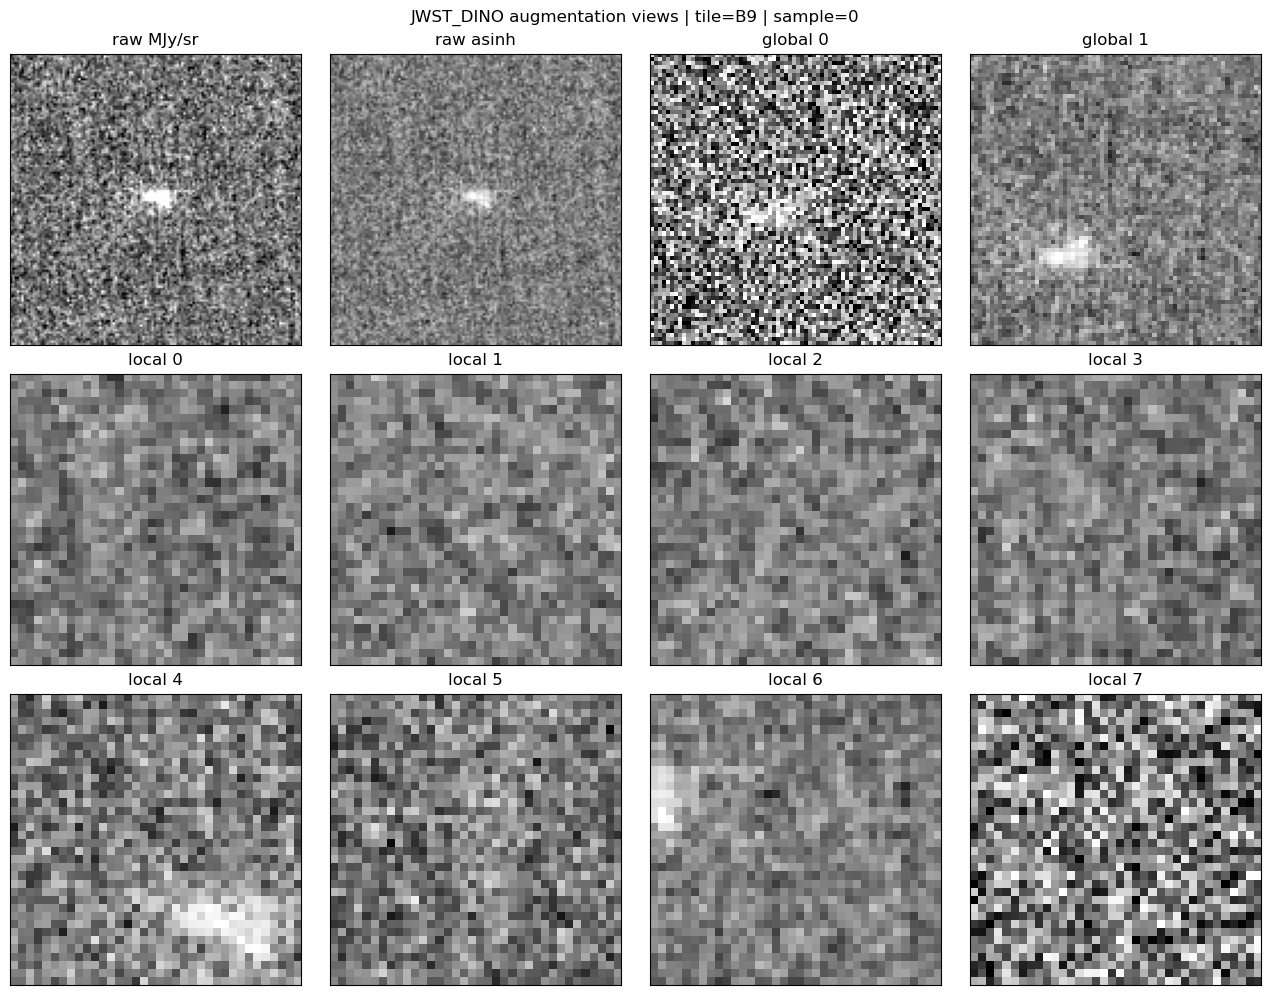

In [11]:
def chw_to_hw(x):
    if isinstance(x, torch.Tensor):
        x = x.detach().cpu().numpy()
    return np.asarray(x).squeeze()


def robust_limits(arrays, q=(1, 99)):
    vals = np.concatenate([np.ravel(a[np.isfinite(a)]) for a in arrays])
    if vals.size == 0:
        return 0.0, 1.0
    lo, hi = np.percentile(vals, q)
    if not np.isfinite(lo) or not np.isfinite(hi) or lo == hi:
        lo, hi = float(np.nanmin(vals)), float(np.nanmax(vals))
    return lo, hi


raw = chw_to_hw(raw_tensor)
raw_asinh = chw_to_hw(torch.from_numpy(AsinhStretch(return_channel_pos=0)(raw_tensor.numpy())))

global_imgs = [chw_to_hw(x) for x in views["global_crops"]]
local_imgs = [chw_to_hw(x) for x in views["local_crops"]]

raw_vmin, raw_vmax = robust_limits([raw], q=(0.5, 99.5))
aug_vmin, aug_vmax = robust_limits([raw_asinh, *global_imgs, *local_imgs], q=(0.5, 99.5))

ncols = 4
panels = [("raw MJy/sr", raw, raw_vmin, raw_vmax), ("raw asinh", raw_asinh, aug_vmin, aug_vmax)]
panels += [(f"global {i}", img, aug_vmin, aug_vmax) for i, img in enumerate(global_imgs)]
panels += [(f"local {i}", img, aug_vmin, aug_vmax) for i, img in enumerate(local_imgs)]

nrows = int(np.ceil(len(panels) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(3.2 * ncols, 3.2 * nrows), constrained_layout=True)
axes = np.asarray(axes).reshape(-1)

for ax, (title, img, vmin, vmax) in zip(axes, panels):
    ax.imshow(img, origin="lower", cmap="gray", vmin=vmin, vmax=vmax)
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])

for ax in axes[len(panels):]:
    ax.axis("off")

fig.suptitle(f"JWST_DINO augmentation views | tile={tile} | sample={SAMPLE_INDEX}", y=1.02)
plt.show()

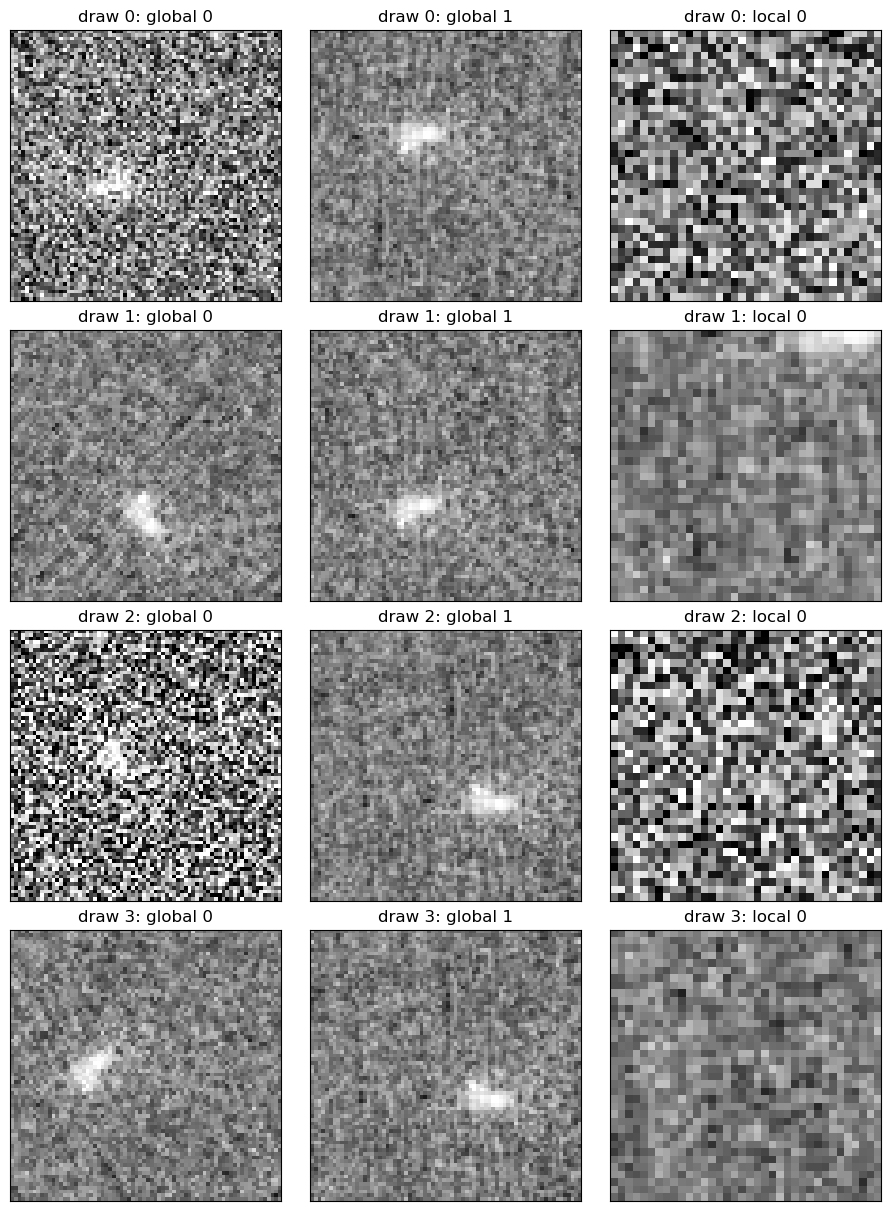

In [12]:
# Re-run this cell to sample several augmentation draws for the same object.
N_DRAWS = 4

fig, axes = plt.subplots(N_DRAWS, 3, figsize=(9, 3 * N_DRAWS), constrained_layout=True)
for r in range(N_DRAWS):
    views_r = aug(raw_tensor.clone(), tile=tile)
    imgs = [
        ("global 0", chw_to_hw(views_r["global_crops"][0])),
        ("global 1", chw_to_hw(views_r["global_crops"][1])),
        ("local 0", chw_to_hw(views_r["local_crops"][0])),
    ]
    for c, (title, img) in enumerate(imgs):
        ax = axes[r, c]
        ax.imshow(img, origin="lower", cmap="gray", vmin=aug_vmin, vmax=aug_vmax)
        ax.set_title(f"draw {r}: {title}")
        ax.set_xticks([])
        ax.set_yticks([])

plt.show()